<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/LSTM_Ridge_Bayesian_1%2C2%2C3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# ================== IMPORTS ==================
import os
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# ---- Optuna for Bayesian optimization ----
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ================== CONFIG / CONSTANTS ==================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

tf.random.set_seed(42)
np.random.seed(42)

INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

TEST_SET_DAYS = 60
VAL_DAYS = 90
N_SPLITS = 2
N_TIMESTEPS = 7
MAPE_EPSILON = 1e-6

TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

LSTM_EPOCHS = 50
LSTM_BATCH_SIZE = 32

# Optuna optimization settings
USE_CONTINUOUS_SPACE = True   # automatic continuous values
N_TRIALS = 25                 # adjust for runtime

In [30]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)

def create_sequences(data, target, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)

def build_lstm_hybrid_model(input_shape_lstm, lr, units):
    lstm_input = Input(shape=input_shape_lstm, name='lstm_input')
    lstm_out = LSTM(units, return_sequences=False)(lstm_input)
    dense_hidden = Dense(units // 2, activation='relu')(lstm_out)
    output = Dense(1, activation='linear', name='output')(dense_hidden)
    model = Model(inputs=lstm_input, outputs=output)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')
    return model

def dynamic_weights(y_true, y_pred_a, y_pred_b):
    rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_a))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_pred_b))
    total = rmse_a + rmse_b if (rmse_a + rmse_b) > 0 else 1.0
    w_a = 1 - (rmse_a / total)
    w_b = 1 - w_a
    return w_a, w_b

# ================== PLOTTING ==================
plt.style.use("seaborn-v0_8-whitegrid")

def plot_test_results(test_df, center_name, meal_period):
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'],
             label='Actual Revenue', marker='o', color='blue')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'],
             label='Predicted Revenue', marker='x', color='orange')
    plt.axvspan(test_df['Date'].min(), test_df['Date'].max(),
                color='lightgrey', alpha=0.2, label='Test Period')
    plt.title(f'Actual vs Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout()
    plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.scatter(residuals_df['Date'], residuals_df['Residual'],
                marker='.', color='grey', alpha=0.6, label='Residuals')
    plt.axhline(0, color='red', linestyle='--', label='Zero Line')
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout()
    plt.show()

In [31]:
# ================== CV SCORING ==================
def score_ensemble_lstm_and_weights(params, X_train_full, Y_train_full, tscv,
                                    raw_target_col, numeric_features, categorical_features):
    lr, units, alpha = params
    fold_rmses, fold_w_lstm, fold_w_ridge = [], [], []

    for train_idx, val_idx in tscv.split(X_train_full):
        X_train_cv_raw, X_val_raw = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        Y_train_cv = Y_train_full.iloc[train_idx][raw_target_col]
        Y_val = Y_train_full.iloc[val_idx][raw_target_col]

        scaler = StandardScaler()
        X_train_num_scaled = scaler.fit_transform(X_train_cv_raw[numeric_features])
        X_val_num_scaled = scaler.transform(X_val_raw[numeric_features])

        X_train_cv_scaled = pd.concat(
            [pd.DataFrame(X_train_num_scaled, columns=numeric_features, index=X_train_cv_raw.index),
             X_train_cv_raw[categorical_features]], axis=1)
        X_val_scaled = pd.concat(
            [pd.DataFrame(X_val_num_scaled, columns=numeric_features, index=X_val_raw.index),
             X_val_raw[categorical_features]], axis=1)

        X_seq_train, Y_seq_train = create_sequences(X_train_cv_scaled.values, Y_train_cv.values, N_TIMESTEPS)
        X_seq_val, Y_seq_val = create_sequences(X_val_scaled.values, Y_val.values, N_TIMESTEPS)
        if len(X_seq_train) == 0 or len(X_seq_val) == 0:
            continue

        X_ridge_train = X_train_cv_scaled.iloc[N_TIMESTEPS:]
        X_ridge_val = X_val_scaled.iloc[N_TIMESTEPS:]
        Y_ridge_train = Y_train_cv.iloc[N_TIMESTEPS:]

        tf.keras.backend.clear_session()
        lstm_model = build_lstm_hybrid_model((N_TIMESTEPS, X_seq_train.shape[2]), lr, units)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        lstm_model.fit(X_seq_train, Y_seq_train,
                       validation_data=(X_seq_val, Y_seq_val),
                       epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH_SIZE,
                       callbacks=[es_callback], verbose=0)
        y_pred_lstm = lstm_model.predict(X_seq_val, verbose=0).flatten()

        ridge_model = Ridge(alpha=alpha).fit(X_ridge_train, Y_ridge_train)
        y_pred_ridge = ridge_model.predict(X_ridge_val).flatten()

        min_len = min(len(Y_seq_val), len(y_pred_lstm), len(y_pred_ridge))
        if min_len == 0:
            continue

        Y_seq_val_trunc = Y_seq_val[:min_len]
        y_pred_lstm_trunc = y_pred_lstm[:min_len]
        y_pred_ridge_trunc = y_pred_ridge[:min_len]

        w_lstm, w_ridge = dynamic_weights(Y_seq_val_trunc, y_pred_lstm_trunc, y_pred_ridge_trunc)
        y_pred_val_ens = (w_lstm * y_pred_lstm_trunc) + (w_ridge * y_pred_ridge_trunc)

        rmse = np.sqrt(mean_squared_error(Y_seq_val_trunc, y_pred_val_ens))
        fold_rmses.append(rmse)
        fold_w_lstm.append(w_lstm)
        fold_w_ridge.append(w_ridge)

    return (np.mean(fold_rmses) if fold_rmses else float('inf'),
            float(np.mean(fold_w_lstm)) if fold_w_lstm else 0.5,
            float(np.mean(fold_w_ridge)) if fold_w_ridge else 0.5)

In [32]:
# ================== OPTUNA OBJECTIVE ==================
def _optuna_objective(trial, X_train_full, Y_train_full, tscv,
                      raw_target_col, numeric_features, categorical_features):
    """
    Optuna objective: sample hyperparameters, run leakage-free CV, return avg RMSE.
    Uses continuous/log-scaled ranges when USE_CONTINUOUS_SPACE=True.
    """
    if USE_CONTINUOUS_SPACE:
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        units = trial.suggest_categorical("units", [32, 64, 128])
        alpha = trial.suggest_float("alpha", 1e-1, 1e2, log=True)
    else:
        lr = trial.suggest_categorical("lr", [1e-4, 5e-4, 1e-3, 5e-3, 1e-2])
        units = trial.suggest_categorical("units", [32, 64, 128])
        alpha = trial.suggest_categorical("alpha", [0.1, 1.0, 10.0, 100.0])

    avg_rmse, _, _ = score_ensemble_lstm_and_weights(
        params=(lr, units, alpha),
        X_train_full=X_train_full,
        Y_train_full=Y_train_full,
        tscv=tscv,
        raw_target_col=raw_target_col,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )

    trial.report(avg_rmse, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return avg_rmse


def run_optuna_for_target(X_train_full, Y_train_full, tscv,
                          raw_target_col, numeric_features, categorical_features,
                          study_name="lstm_ridge_opt"):
    """
    Run Optuna study for one target column, return best params and CV-averaged weights.
    """
    sampler = optuna.samplers.TPESampler(seed=42)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5)

    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner,
                                study_name=f"{study_name}_{raw_target_col}")

    study.optimize(lambda trial: _optuna_objective(
        trial, X_train_full, Y_train_full, tscv,
        raw_target_col, numeric_features, categorical_features),
        n_trials=N_TRIALS, show_progress_bar=False)

    best_trial = study.best_trial
    best_lr = best_trial.params["lr"]
    best_units = best_trial.params["units"]
    best_alpha = best_trial.params["alpha"]

    # Recompute average weights with best params
    best_rmse, avg_w_lstm, avg_w_ridge = score_ensemble_lstm_and_weights(
        params=(best_lr, best_units, best_alpha),
        X_train_full=X_train_full,
        Y_train_full=Y_train_full,
        tscv=tscv,
        raw_target_col=raw_target_col,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )

    return (best_lr, best_units, best_alpha), (avg_w_lstm, avg_w_ridge), best_rmse

In [33]:
# ================== MAIN TRAINING FUNCTION ==================
def train_and_plot_for_center(df_center, center_name):
    """
    Train hybrid LSTM + Ridge model for one revenue center.
    Uses Optuna to optimize hyperparameters via leakage-free CV,
    retrains on full training set, evaluates on test set, and plots results.
    """
    # Feature engineering
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # Train/test split by date
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # TimeSeriesSplit with gap to avoid soft leakage
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS, gap=N_TIMESTEPS)

    # Separate features
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    # Train each meal period separately
    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')

        print(f"\n⚙️ Optuna search for {center_name} - {meal_period}: {N_TRIALS} trials")

        # ---- Optuna optimization ----
        best_params, best_weights, best_rmse = run_optuna_for_target(
            X_train_full=X_train_full,
            Y_train_full=Y_train_full,
            tscv=tscv,
            raw_target_col=raw_target_col,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            study_name=f"{center_name.replace(' ', '_')}"
        )

        best_lr, best_units, best_alpha = best_params
        w_lstm_cv, w_ridge_cv = best_weights

        print(f"✅ Best Params: LR={best_lr:.5f}, Units={best_units}, Alpha={best_alpha:.2f}, Avg CV RMSE={best_rmse:.2f}")
        print(f"✅ Ensemble weights (CV): LSTM={w_lstm_cv:.3f}, Ridge={w_ridge_cv:.3f}")

        # Final training on full training set
        final_scaler = StandardScaler()
        X_train_full_scaled = pd.DataFrame(
            final_scaler.fit_transform(X_train_full[numeric_features]),
            columns=numeric_features,
            index=X_train_full.index
        )
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1).apply(
            pd.to_numeric, errors='coerce').fillna(0)

        Y_train_target = Y_train_full[raw_target_col].values
        X_seq_train_final, Y_seq_train_final = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        if len(X_seq_train_final) == 0:
            print(f"Not enough data for LSTM sequences in {center_name} - {meal_period}. Skipping.")
            continue

        X_ridge_train_final = X_train_final.iloc[N_TIMESTEPS:]
        Y_ridge_train_final = Y_train_full[raw_target_col].iloc[N_TIMESTEPS:]

        tf.keras.backend.clear_session()
        final_lstm_model = build_lstm_hybrid_model((N_TIMESTEPS, X_seq_train_final.shape[2]), best_lr, best_units)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
        final_lstm_model.fit(X_seq_train_final, Y_seq_train_final,
                             epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH_SIZE,
                             callbacks=[es_callback], verbose=0)

        final_ridge_model = Ridge(alpha=best_alpha).fit(X_ridge_train_final, Y_ridge_train_final)

        # Prepare test set
        X_test_scaled = pd.DataFrame(
            final_scaler.transform(df_test_full[numeric_features]),
            columns=numeric_features,
            index=df_test_full.index
        )
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).apply(
            pd.to_numeric, errors='coerce').fillna(0)
        Y_test_raw = df_test_full[raw_target_col].values

        # Build continuous sequence for test
        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)

        y_test_lstm = final_lstm_model.predict(X_seq_test, verbose=0).flatten()
        y_test_ridge = final_ridge_model.predict(X_test_final).flatten()

        min_len_test = min(len(Y_test_raw), len(y_test_lstm), len(y_test_ridge))
        if min_len_test <= 0:
            print(f"Skipping final prediction for {center_name} - {meal_period}: Test data too short.")
            continue

        Y_test_raw_trunc = Y_test_raw[:min_len_test]
        y_test_lstm_trunc = y_test_lstm[:min_len_test]
        y_test_ridge_trunc = y_test_ridge[:min_len_test]

        # Ensemble using CV-derived weights (no test leakage)
        y_test_ens = (w_lstm_cv * y_test_lstm_trunc) + (w_ridge_cv * y_test_ridge_trunc)

        test_rmse = np.sqrt(mean_squared_error(Y_test_raw_trunc, y_test_ens))
        test_mape = np.mean(np.abs(Y_test_raw_trunc - y_test_ens) /
                            np.maximum(Y_test_raw_trunc, MAPE_EPSILON)) * 100

        print(f"\n--- FINAL TEST RESULTS ({center_name} - {meal_period}) ---")
        print(f"TEST RMSE: {test_rmse:.2f}, TEST MAPE: {test_mape:.2f}%")

        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:min_len_test],
            'Actual_Revenue': Y_test_raw_trunc,
            'Predicted_Revenue': y_test_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)


================= Revenue Centre 1 =================

⚙️ Optuna search for Revenue Centre 1 - BreakFast: 25 trials
✅ Best Params: LR=0.00993, Units=128, Alpha=8.59, Avg CV RMSE=959.99
✅ Ensemble weights (CV): LSTM=0.465, Ridge=0.535

--- FINAL TEST RESULTS (Revenue Centre 1 - BreakFast) ---
TEST RMSE: 1052.37, TEST MAPE: 387053592.07%


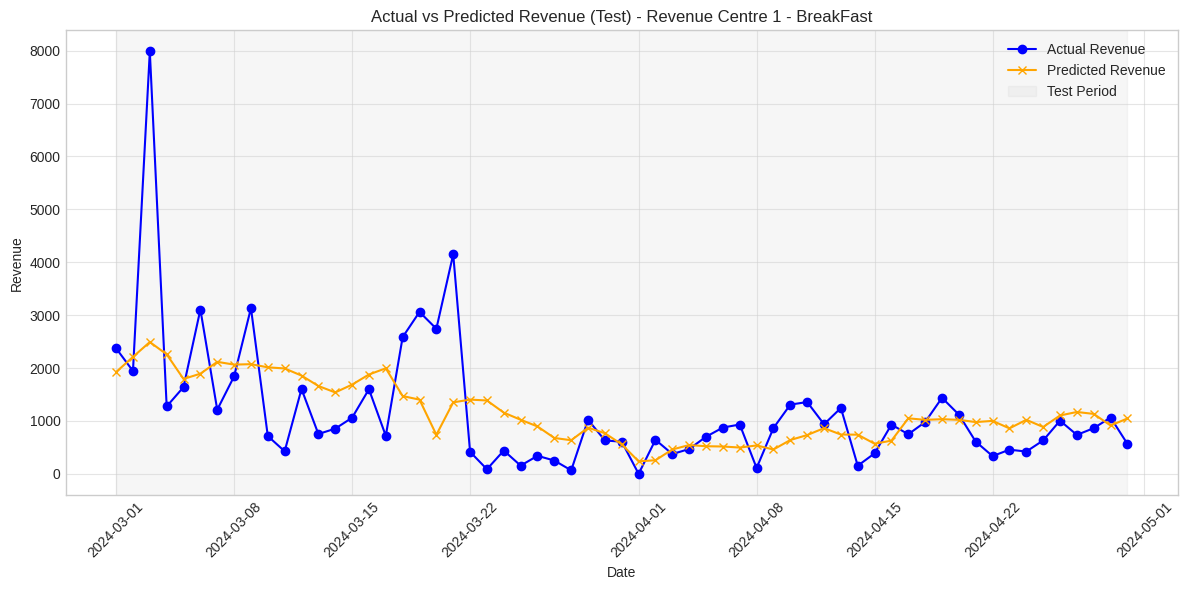

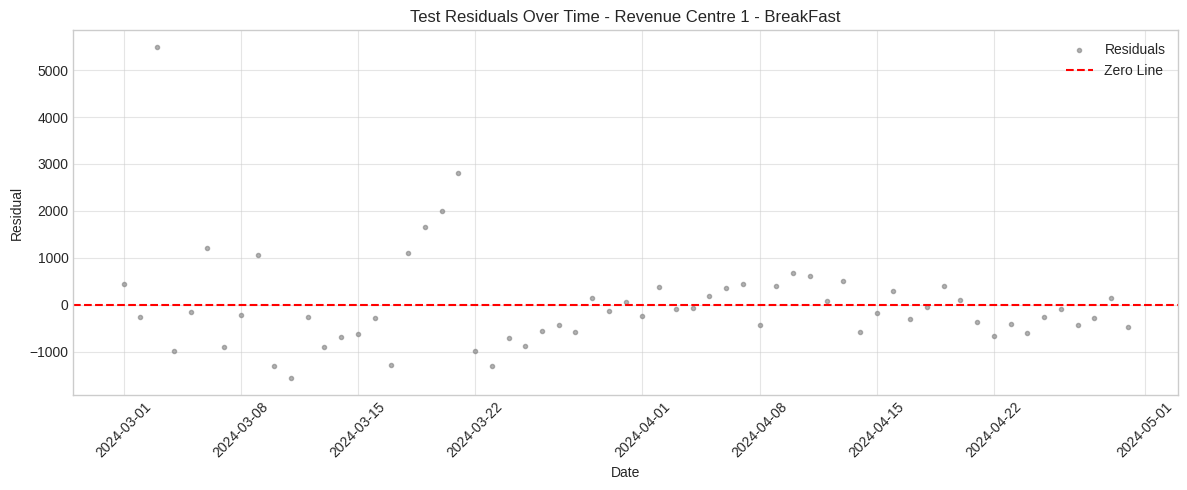


⚙️ Optuna search for Revenue Centre 1 - Dinner: 25 trials
✅ Best Params: LR=0.00989, Units=128, Alpha=7.12, Avg CV RMSE=1560.05
✅ Ensemble weights (CV): LSTM=0.445, Ridge=0.555

--- FINAL TEST RESULTS (Revenue Centre 1 - Dinner) ---
TEST RMSE: 1617.22, TEST MAPE: 72.94%


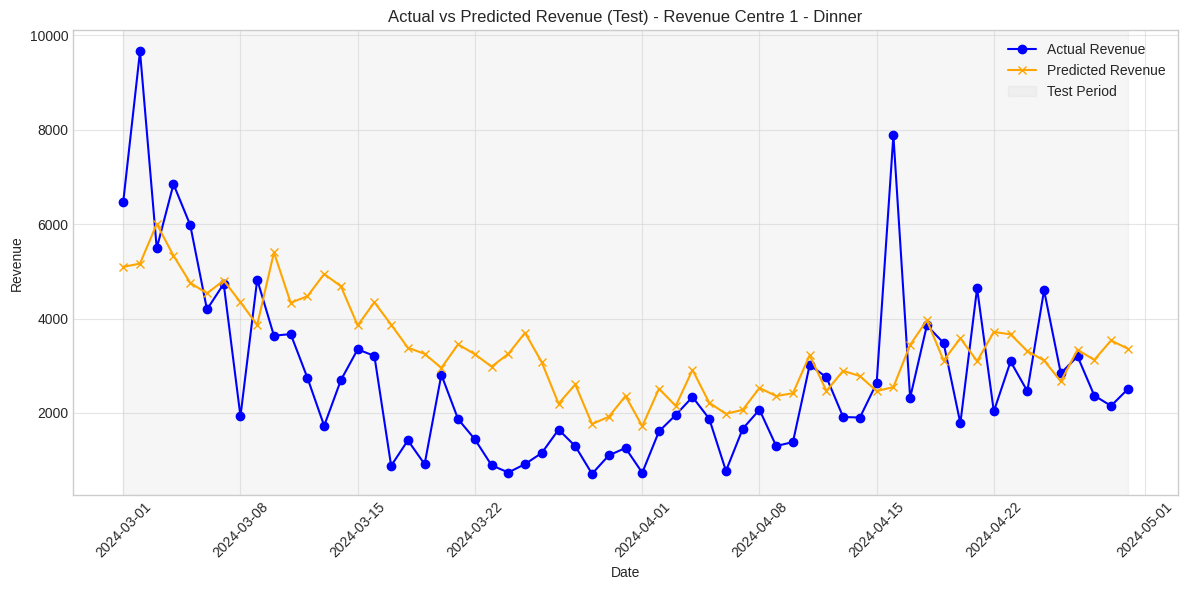

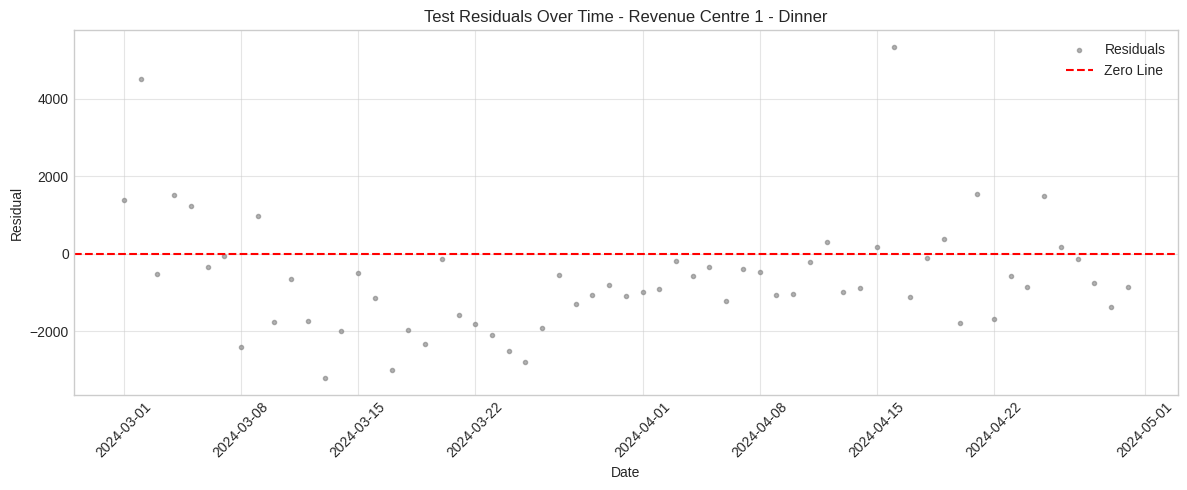


⚙️ Optuna search for Revenue Centre 1 - Lunch: 25 trials
✅ Best Params: LR=0.00891, Units=128, Alpha=8.75, Avg CV RMSE=791.12
✅ Ensemble weights (CV): LSTM=0.488, Ridge=0.512

--- FINAL TEST RESULTS (Revenue Centre 1 - Lunch) ---
TEST RMSE: 649.36, TEST MAPE: 2078170813.59%


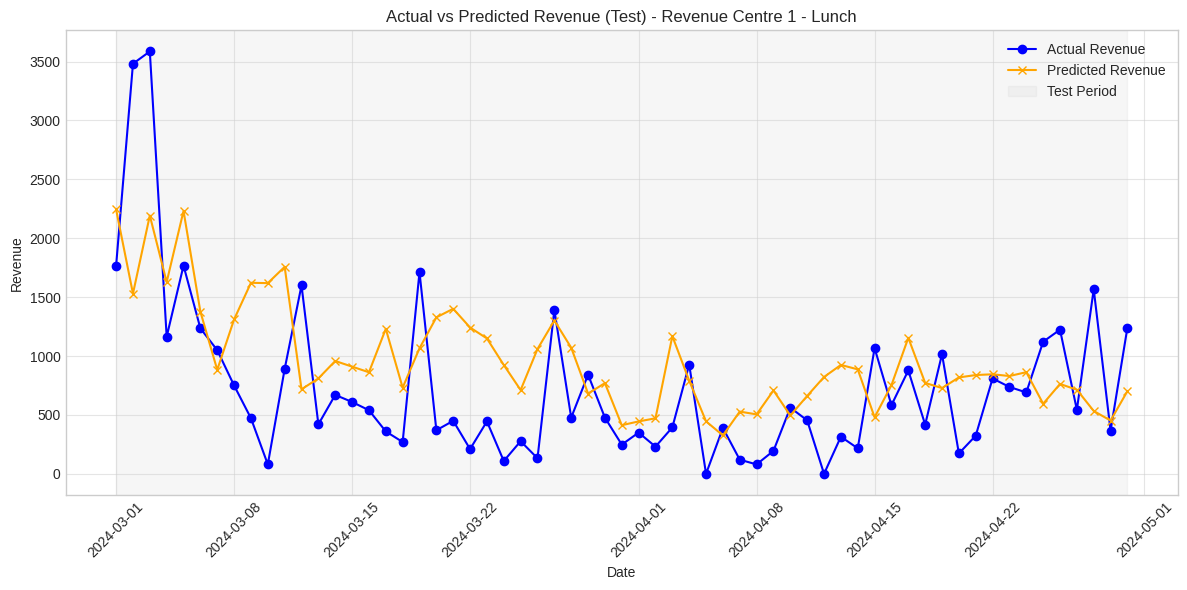

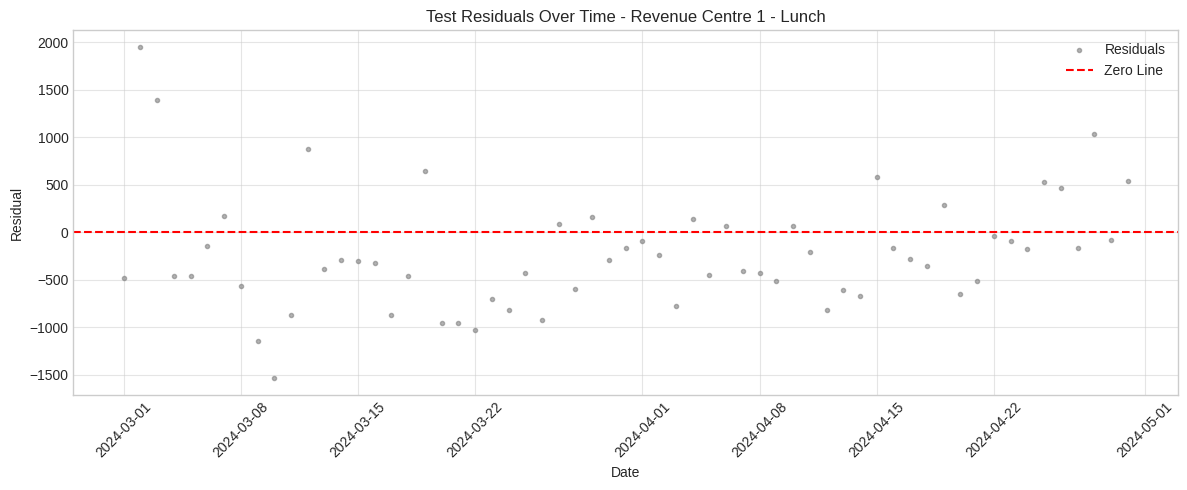

In [34]:
# ================== LOAD CENTERS AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df


if __name__ == '__main__':
    for center_id in range(0, 1):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")


================= Revenue Centre 2 =================

⚙️ Optuna search for Revenue Centre 2 - BreakFast: 25 trials
✅ Best Params: LR=0.00574, Units=128, Alpha=6.46, Avg CV RMSE=350.35
✅ Ensemble weights (CV): LSTM=0.521, Ridge=0.479

--- FINAL TEST RESULTS (Revenue Centre 2 - BreakFast) ---
TEST RMSE: 470.82, TEST MAPE: 11608035380.43%


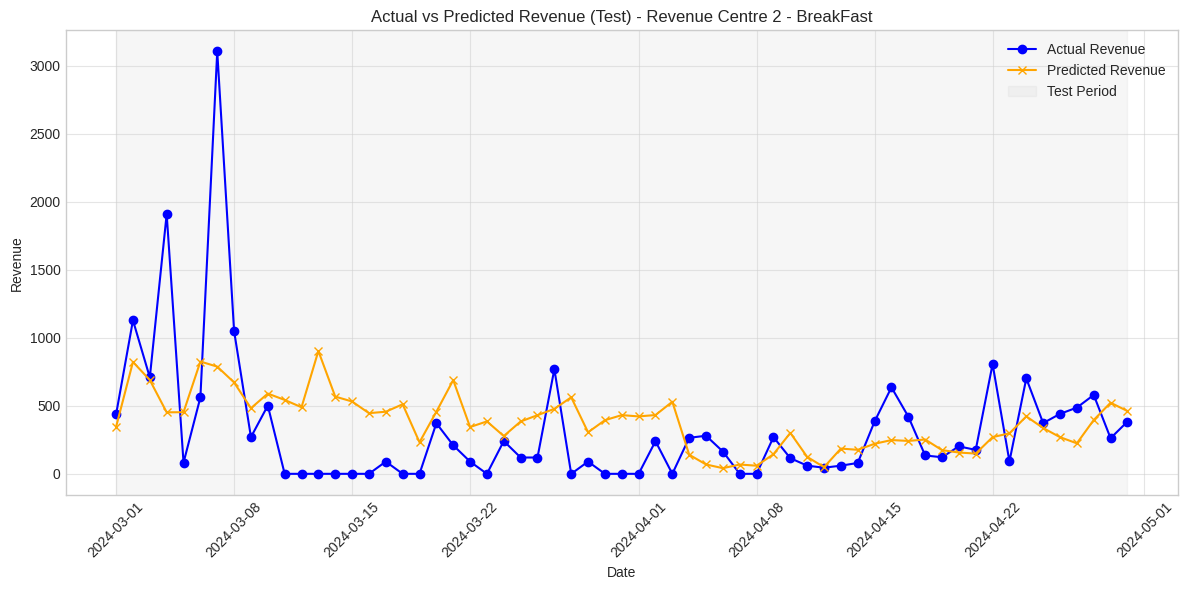

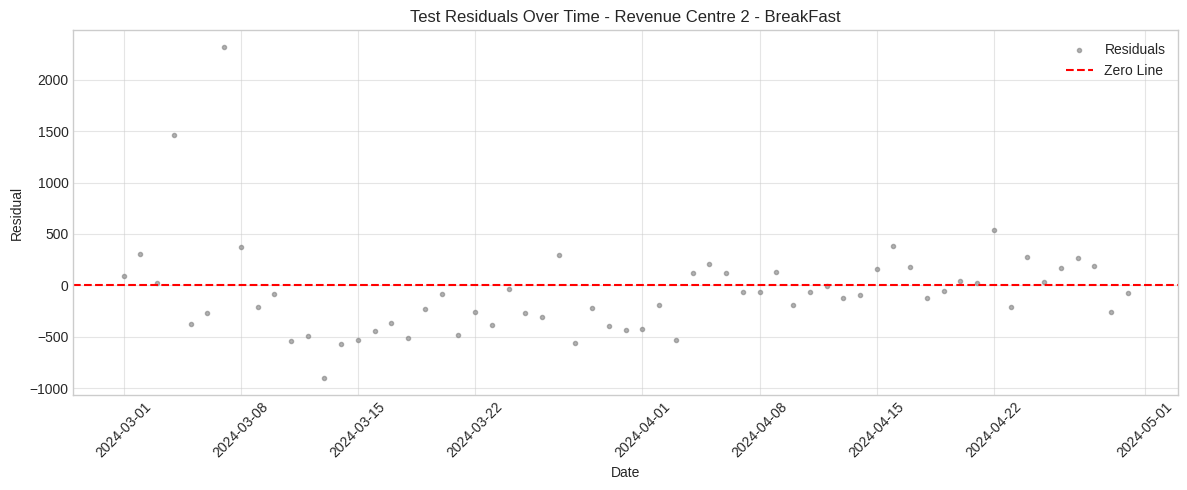


⚙️ Optuna search for Revenue Centre 2 - Dinner: 25 trials
✅ Best Params: LR=0.00554, Units=128, Alpha=27.82, Avg CV RMSE=888.23
✅ Ensemble weights (CV): LSTM=0.505, Ridge=0.495

--- FINAL TEST RESULTS (Revenue Centre 2 - Dinner) ---
TEST RMSE: 757.90, TEST MAPE: 9089135480.60%


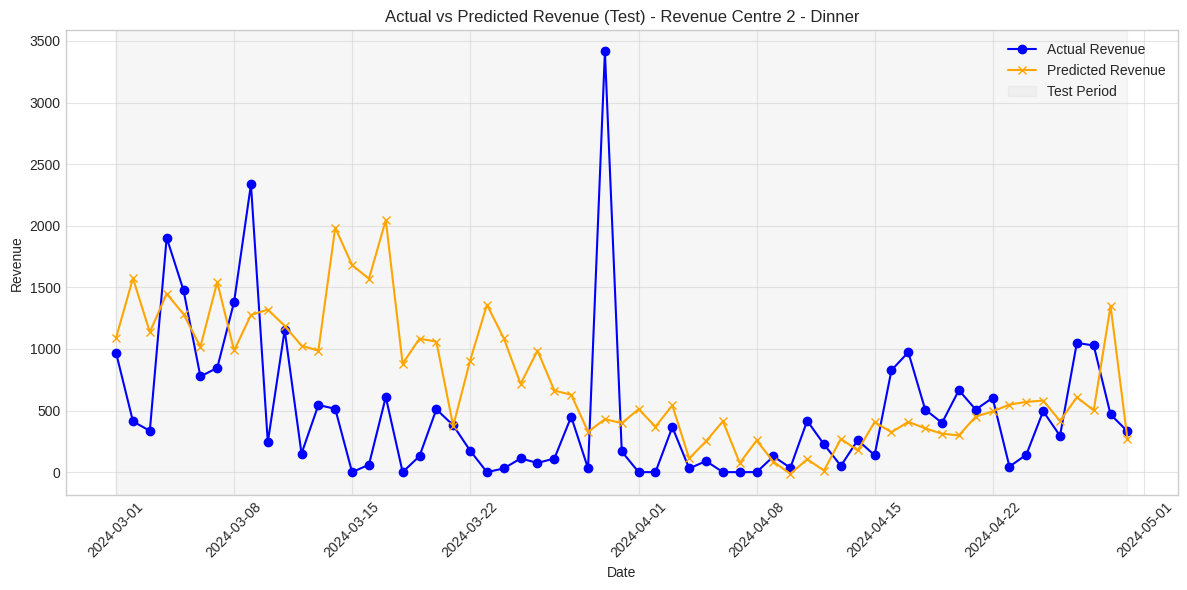

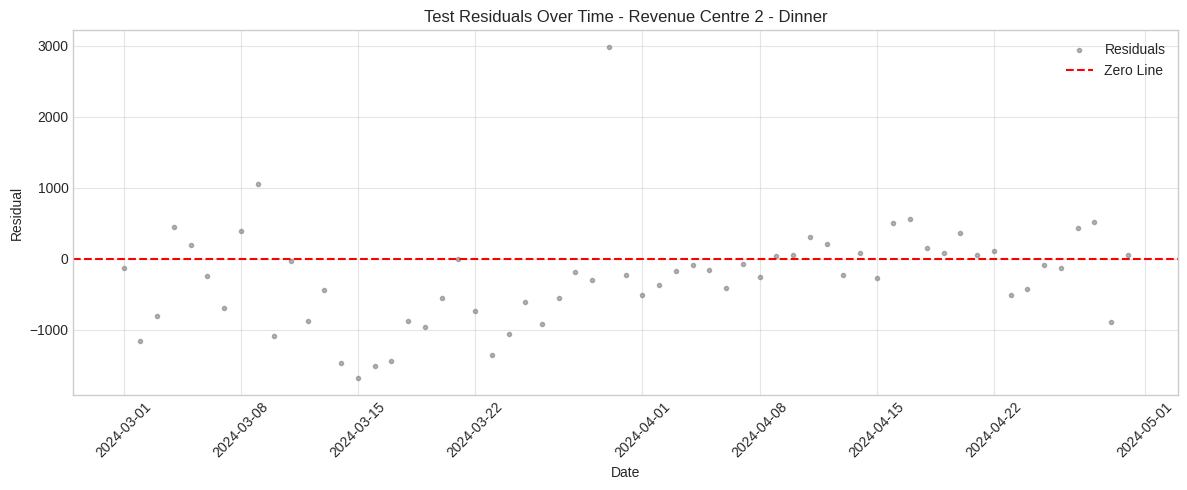


⚙️ Optuna search for Revenue Centre 2 - Lunch: 25 trials
✅ Best Params: LR=0.00906, Units=128, Alpha=3.05, Avg CV RMSE=402.12
✅ Ensemble weights (CV): LSTM=0.520, Ridge=0.480

--- FINAL TEST RESULTS (Revenue Centre 2 - Lunch) ---
TEST RMSE: 925.36, TEST MAPE: 4768242668.86%


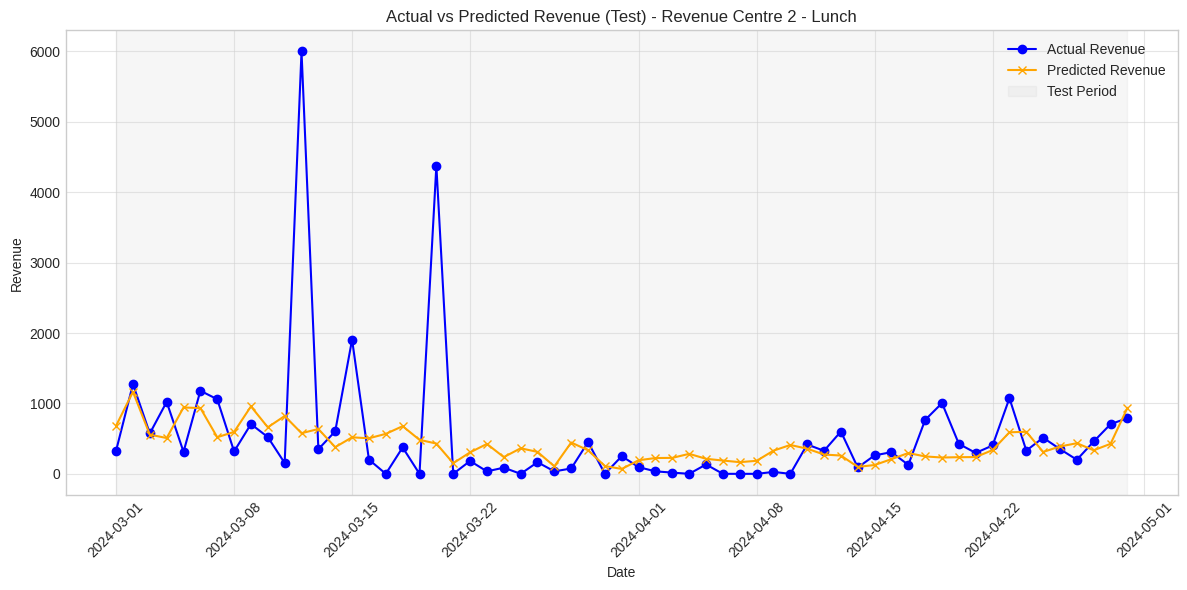

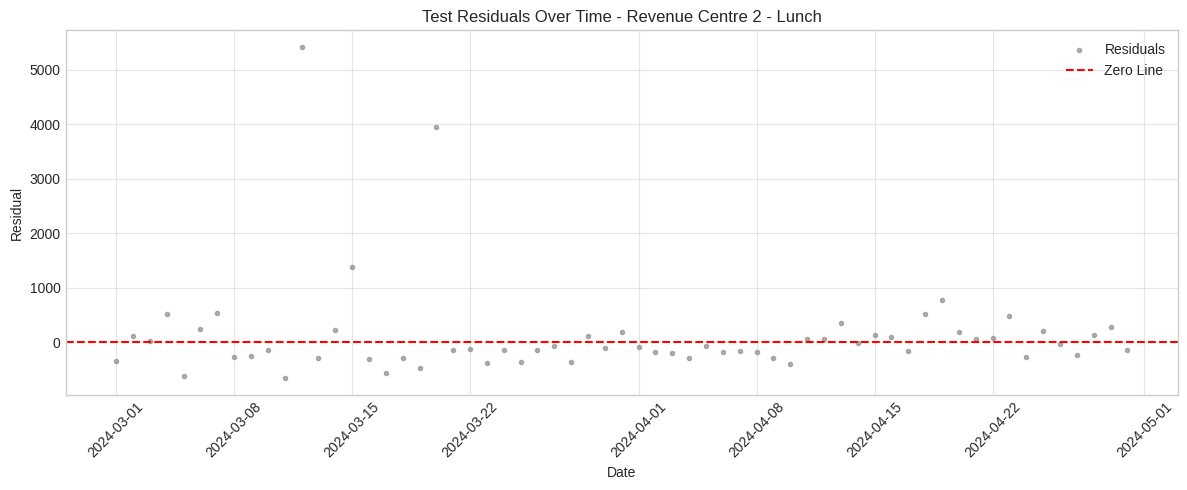

In [35]:
# ================== LOAD CENTERS AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df


if __name__ == '__main__':
    for center_id in range(1, 2):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")


================= Revenue Centre 3 =================

⚙️ Optuna search for Revenue Centre 3 - BreakFast: 25 trials
✅ Best Params: LR=0.00167, Units=128, Alpha=2.33, Avg CV RMSE=384.08
✅ Ensemble weights (CV): LSTM=0.508, Ridge=0.492

--- FINAL TEST RESULTS (Revenue Centre 3 - BreakFast) ---
TEST RMSE: 330.26, TEST MAPE: 7936276034.12%


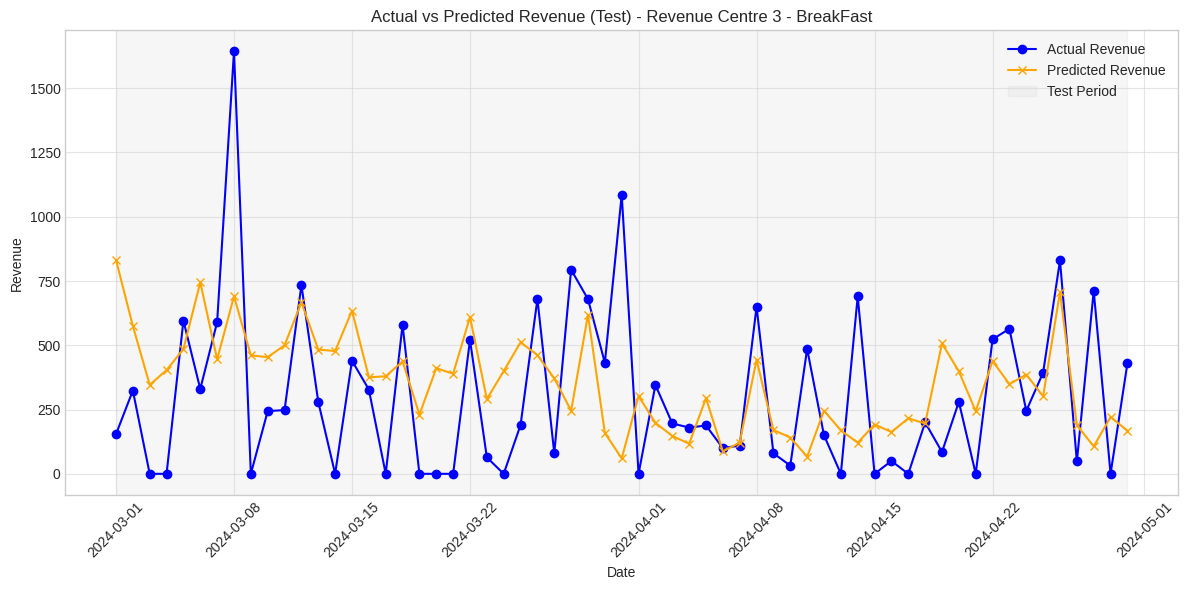

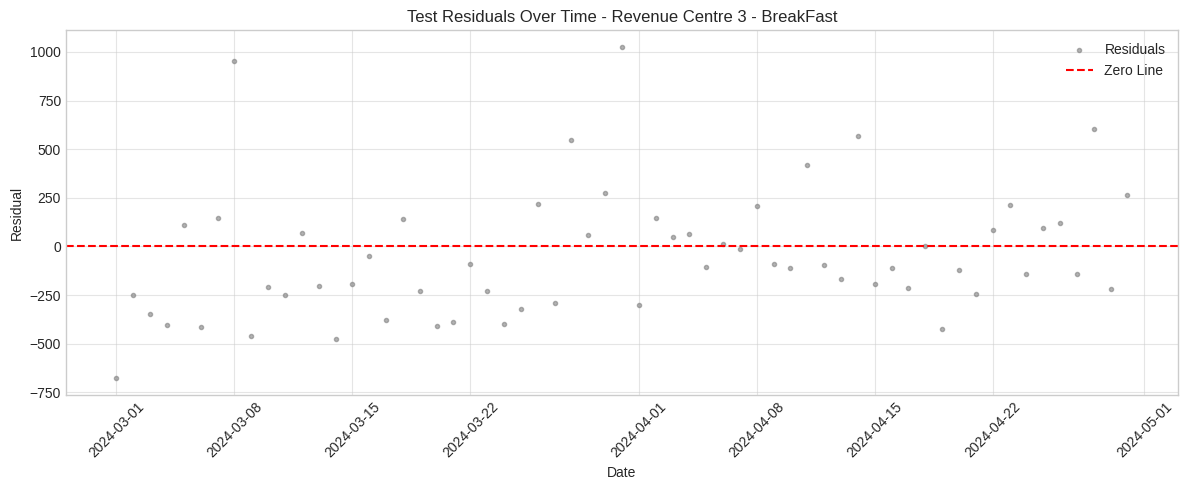


⚙️ Optuna search for Revenue Centre 3 - Dinner: 25 trials
✅ Best Params: LR=0.00926, Units=128, Alpha=3.05, Avg CV RMSE=4611.35
✅ Ensemble weights (CV): LSTM=0.411, Ridge=0.589

--- FINAL TEST RESULTS (Revenue Centre 3 - Dinner) ---
TEST RMSE: 8849.56, TEST MAPE: 51.38%


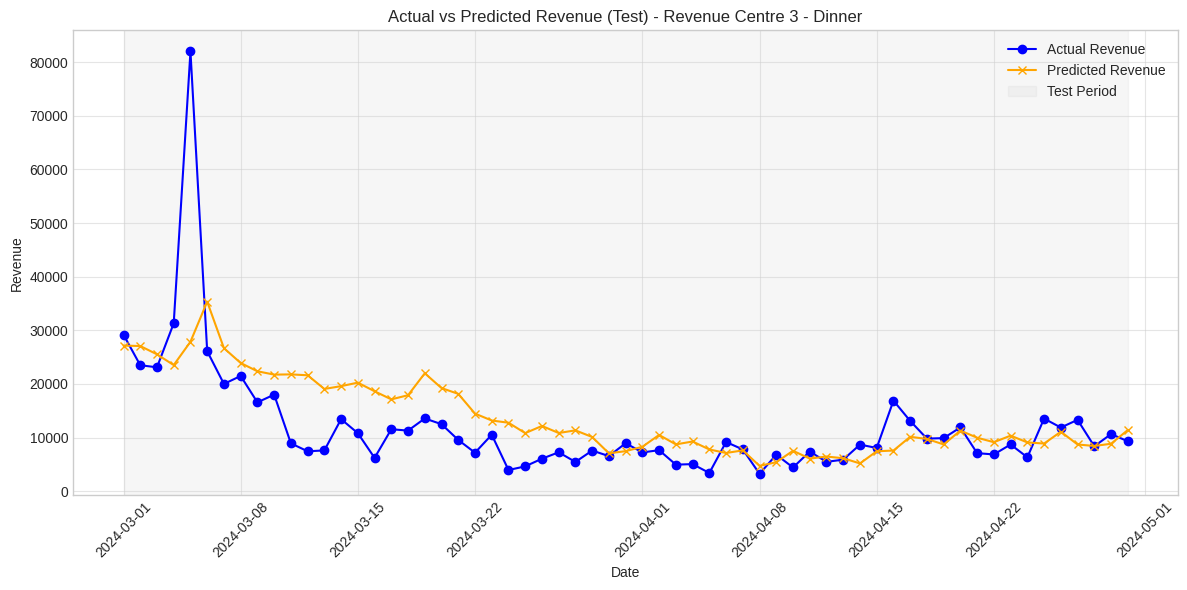

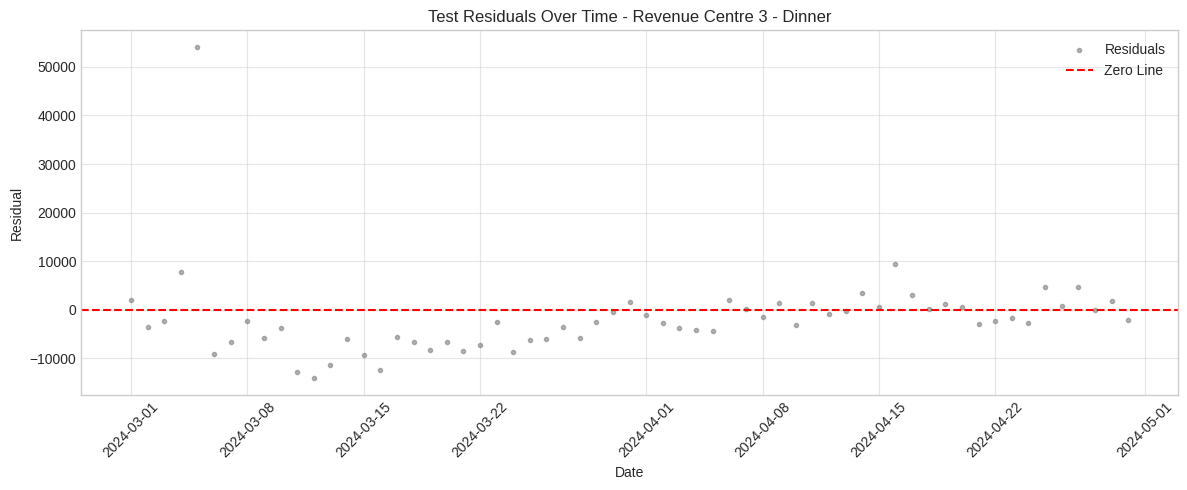


⚙️ Optuna search for Revenue Centre 3 - Lunch: 25 trials
✅ Best Params: LR=0.00364, Units=128, Alpha=3.05, Avg CV RMSE=1068.50
✅ Ensemble weights (CV): LSTM=0.484, Ridge=0.516

--- FINAL TEST RESULTS (Revenue Centre 3 - Lunch) ---
TEST RMSE: 1193.22, TEST MAPE: 55.26%


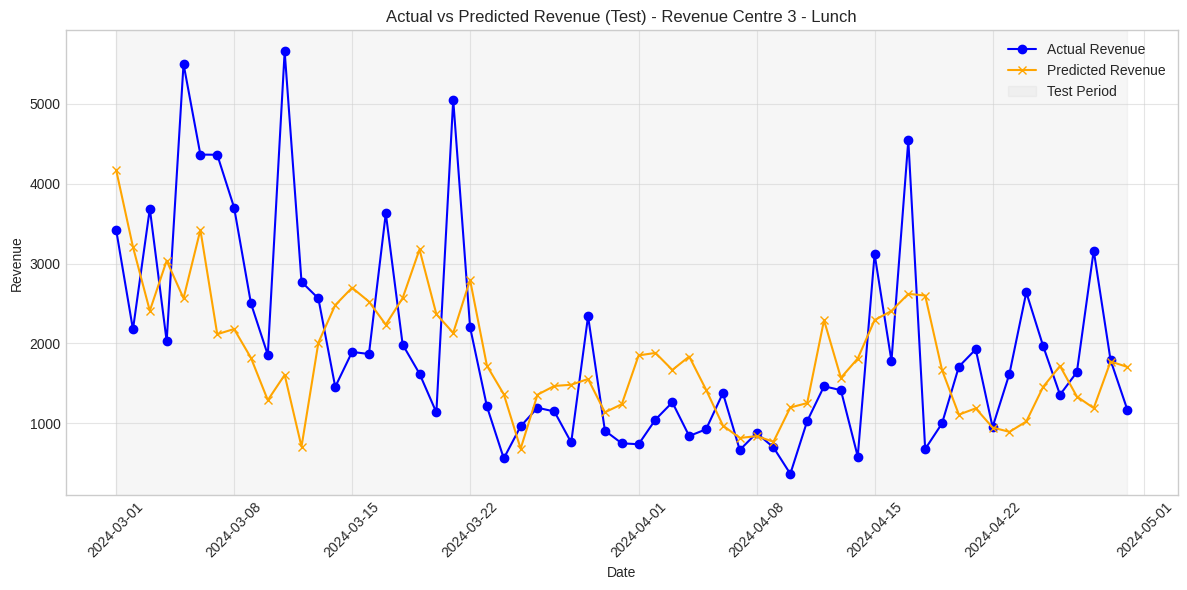

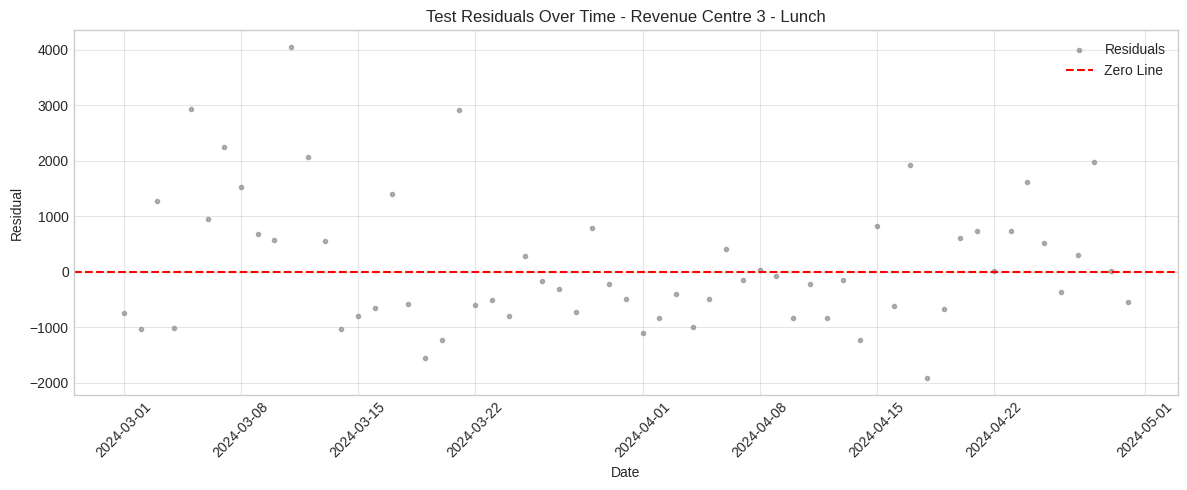

In [36]:
# ================== LOAD CENTERS AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df


if __name__ == '__main__':
    for center_id in range(2, 3):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")